# A galactic-binary block for enchilada

This notebook plugs a **real LISA source-class sampler** into the enchilada
`Wheel`. To make it obvious *what is enchilada and what is not*, everything that
is **not** enchilada — the GBGPU waveform helpers, the LISA noise model, the data
injector, and the `GBBlock` itself — lives in a separate module,
[`gb_model.py`](gb_model.py). This notebook only:

1. imports enchilada's `Residuals` and `Wheel`,
2. imports the model pieces from `gb_model`,
3. builds the dataset, wraps it in a `Residuals`, runs it through a `Wheel`, and
   reads the result back.

So every enchilada touchpoint is visible here; the physics is behind the import.

- **waveforms** — [GBGPU](https://github.com/mikekatz04/GBGPU) (`master`), narrowband TDI;
- **sampler** — [Eryn](https://github.com/mikekatz04/Eryn), inside the block;
- **noise** — fixed LISA sensitivity, carried on `Residuals.noise`, consumed by
  the block via `residual.noise_psd()`.

> **Requires** the LISA stack (`gbgpu`, `eryn`, `lisaanalysistools`) plus
> `matplotlib` and `corner` for the plots, in the same env as `enchilada` — the
> conda env, not enchilada's core `.venv`. Outputs are not committed; run it to
> populate them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# enchilada — the orchestration layer
from enchilada import Residuals, Wheel

# everything that is NOT enchilada (see gb_model.py)
from gb_model import FixedLISANoise, GBBlock, inject_gb, waveform

/Users/aaron/miniconda3/envs/enchilada/lib/python3.14/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


## 1. Define the dataset

enchilada's frequency-domain convention is the one-sided rfft grid of the
underlying time series (`n_samples` counts *time-domain* samples; each tdi array
has length `n_samples // 2 + 1`).

In [2]:
dt = 15.0
N_time = 2**19  # time-domain samples -> pins Tobs, df
Tobs = N_time * dt  # ~91 days
df = 1.0 / Tobs
freqs = np.fft.rfftfreq(N_time, dt)
CHANS = ("A", "E")
NB = 128  # GBGPU template band width (bins)

TRUTH = np.array([2.0e-22, 3.0e-3, 1.0e-16, 0.7])  # amp, f0, fdot, phi0
ANGLES = (0.9, 1.3, 2.1, 0.4)  # iota, psi, lam, beta  (fixed)
PARAMS = ["amp", "f0", "fdot", "phi0"]
print(f"Tobs={Tobs / 86400:.0f} d, df={df:.2e} Hz, grid={freqs.size} bins")

Tobs=91 d, df=1.27e-07 Hz, grid=262145 bins


## 2. Noise model + injected data (both from `gb_model`)

`FixedLISANoise` and `inject_gb` are user code. `inject_gb` returns the raw
channel arrays; **wrapping them in a `Residuals` is where enchilada enters** — and it
is where the fixed noise gets attached so the block can read it back.

In [3]:
noise = FixedLISANoise()
data, info = inject_gb(TRUTH, ANGLES, Tobs, dt, N_time, CHANS, noise, NB=NB, seed=42)
print(
    f"injected GB at f0={TRUTH[1]} Hz, bins {info['band']}, optimal SNR={info['snr']:.1f}"
)

# --- enchilada: the data contract ---
observed = Residuals(
    tdi=data,
    sample_rate=1.0 / dt,
    n_samples=N_time,
    channels=CHANS,
    tdi_generation="1.5",  # A1TDISens is the TDI 1.5 A channel
    observable="fractional_frequency",
    domain="frequency",
    noise=noise,
)  # epoch defaults to 0.0

injected GB at f0=0.003 Hz, bins slice(23529, 23657, None), optimal SNR=64.3


## 3. Run the model through enchilada

Register a `GBBlock` on a `Wheel` and run. The block reads channels, the
grid, and the noise (`residual.noise_psd()`) off the residual the Wheel hands
it — nothing is passed in from here except the residual itself.

In [4]:
BOUNDS = [
    [0.3 * TRUTH[0], 3.0 * TRUTH[0]],
    [TRUTH[1] - 30 * df, TRUTH[1] + 30 * df],
    [0.0, 3.0e-16],
    [0.0, 2 * np.pi],
]

# MCMC sampling budget: total posterior samples = n_walkers * steps_per_cycle * n_cycles
n_walkers, steps_per_cycle, n_cycles = 40, 200, 12
block = GBBlock(
    init=TRUTH,
    bounds=BOUNDS,
    angles=ANGLES,
    band=NB,
    n_walkers=n_walkers,
    steps_per_cycle=steps_per_cycle,
)

wheel = Wheel(observed)  # enchilada
wheel.add(block)  # enchilada


def report(it, w):
    p = block.params
    print(
        f"  cycle {it + 1:2d}: amp={p[0]:.3e}  f0={p[1]:.9f}  fdot={p[2]:.3e}  phi0={p[3]:.3f}"
    )


total = n_walkers * steps_per_cycle * n_cycles
print(
    f"running the Wheel: {total:,} GB samples "
    f"({n_walkers} walkers x {steps_per_cycle} steps x {n_cycles} cycles), "
    f"noise via residual.noise_psd ..."
)
wheel.run(n_cycles, on_cycle=report)  # enchilada drives block.update each cycle

running the Wheel: 96,000 GB samples (40 walkers x 200 steps x 12 cycles), noise via residual.noise_psd ...
  cycle  1: amp=2.063e-22  f0=0.003000001  fdot=1.527e-16  phi0=0.696
  cycle  2: amp=2.078e-22  f0=0.002999997  fdot=1.487e-16  phi0=0.689
  cycle  3: amp=2.068e-22  f0=0.002999997  fdot=1.755e-16  phi0=0.694
  cycle  4: amp=2.067e-22  f0=0.002999997  fdot=1.535e-16  phi0=0.695
  cycle  5: amp=2.072e-22  f0=0.002999997  fdot=1.662e-16  phi0=0.693
  cycle  6: amp=2.070e-22  f0=0.002999997  fdot=1.780e-16  phi0=0.688
  cycle  7: amp=2.070e-22  f0=0.002999997  fdot=1.414e-16  phi0=0.693
  cycle  8: amp=2.072e-22  f0=0.002999997  fdot=1.618e-16  phi0=0.688
  cycle  9: amp=2.080e-22  f0=0.002999997  fdot=1.674e-16  phi0=0.691
  cycle 10: amp=2.077e-22  f0=0.002999997  fdot=1.466e-16  phi0=0.694
  cycle 11: amp=2.077e-22  f0=0.002999997  fdot=1.579e-16  phi0=0.686
  cycle 12: amp=2.076e-22  f0=0.002999997  fdot=1.787e-16  phi0=0.697


## 4. Recovery

All four parameters recover within ~1-2σ of the injection. The deviation on any
single parameter is noise-realization dependent, not a bias: across `seed=42/7/1234`
the amplitude lands at +2.5σ, +1.4σ and -0.2σ respectively.

Two honest caveats, both about the *sampler*, not enchilada:

- **`fdot` is prior-dominated.** 91 days cannot measure a 3 mHz binary's frequency
  drift, so its marginal just rises to the edge of the `[0, 3e-16]` box. Treat it
  as an upper limit, not a measurement.
- **`ntemps=1`, so a few walkers get stuck.** GB likelihoods have real secondary
  peaks at integer frequency-bin offsets; a walker that lands in one never escapes
  at a single temperature. Typically 5-12% of samples end up an alias bin or two
  away, which inflates every error bar if you leave them in — so the cell below
  keeps the dominant mode and reports how much it dropped. Parallel tempering
  (`ntemps > 1`) is the real fix and costs a factor of `ntemps` in likelihood calls.

Cycle the sampling budget up or down with `n_walkers`/`steps_per_cycle`/`n_cycles`
above.

In [ ]:
post_all = block.chain[len(block.chain) // 2 :]  # drop first-half burn-in

converged = np.abs(post_all[:, 1] - TRUTH[1]) < 0.5 * df
post = post_all[converged]
print(
    f"dominant frequency mode: {converged.sum():,}/{len(post_all):,} samples "
    f"({converged.mean():.1%}); {(~converged).sum():,} in adjacent-bin aliases, "
    f"dropped. Parallel tempering (ntemps > 1) would let those walkers escape.\n"
)

print("posterior mean +/- std vs truth:")
for i, p in enumerate(PARAMS):
    m, s = post[:, i].mean(), post[:, i].std()
    z = (m - TRUTH[i]) / s if s else 0.0
    print(f"  {p:5s}: {m:.6e} +/- {s:.2e}   truth {TRUTH[i]:.6e}   ({z:+.1f} sigma)")

dominant frequency mode: 46,800/48,000 samples (97.5%); 1,200 in adjacent-bin aliases, dropped. Parallel tempering (ntemps > 1) would let those walkers escape.

posterior mean +/- std vs truth:
  amp  : 2.076244e-22 +/- 3.16e-24   truth 2.000000e-22   (+2.4 sigma)
  f0   : 3.000001e-03 +/- 9.87e-10   truth 3.000000e-03   (+0.7 sigma)
  fdot : 1.589737e-16 +/- 8.67e-17   truth 1.000000e-16   (+0.7 sigma)
  phi0 : 6.891078e-01 +/- 2.54e-02   truth 7.000000e-01   (-0.4 sigma)


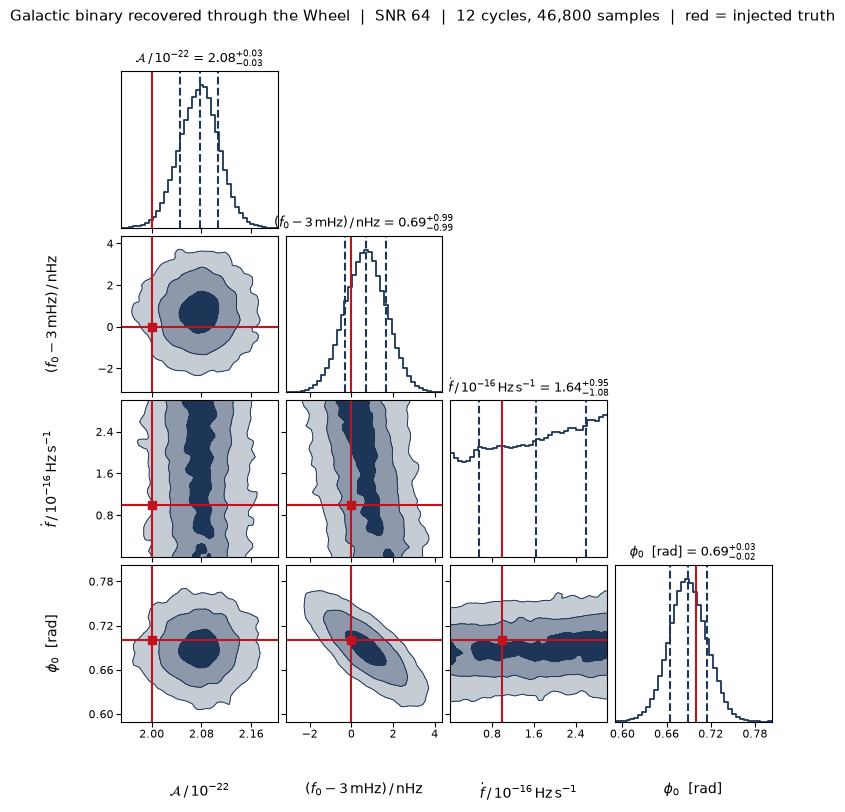

In [ ]:
import corner

SCALE = np.array([1e-22, 1e-9, 1e-16, 1.0])
OFFSET = np.array([0.0, 3.0e-3, 0.0, 0.0])
LABELS = [
    r"$\mathcal{A}\,/\,10^{-22}$",
    r"$(f_0 - 3\,\mathrm{mHz})\,/\,\mathrm{nHz}$",
    r"$\dot{f}\,/\,10^{-16}\,\mathrm{Hz\,s^{-1}}$",
    r"$\phi_0$  [rad]",
]

fig = corner.corner(
    (post - OFFSET) / SCALE,
    labels=LABELS,
    truths=(TRUTH - OFFSET) / SCALE,
    truth_color="#c1121f",
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2.0), 1 - np.exp(-4.5)),
    bins=40,
    max_n_ticks=4,
    labelpad=0.09,
    smooth=0.9,
    smooth1d=0.9,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".2f",
    fill_contours=True,
    plot_datapoints=False,
    plot_density=False,
    color="#1d3557",
    hist_kwargs={"lw": 1.3},
    contour_kwargs={"linewidths": 0.7},
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 9},
)
fig.set_size_inches(7.6, 7.6)
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=8, pad=2)
    for lbl in (*ax.get_xticklabels(), *ax.get_yticklabels()):
        lbl.set_rotation(0)
        lbl.set_ha("center" if lbl in ax.get_xticklabels() else "right")
fig.suptitle(
    f"Galactic binary recovered through the Wheel  |  SNR {info['snr']:.0f}  |  "
    f"{n_cycles} cycles, {len(post):,} samples  |  red = injected truth",
    fontsize=10.5,
    y=1.04,
)
plt.show()

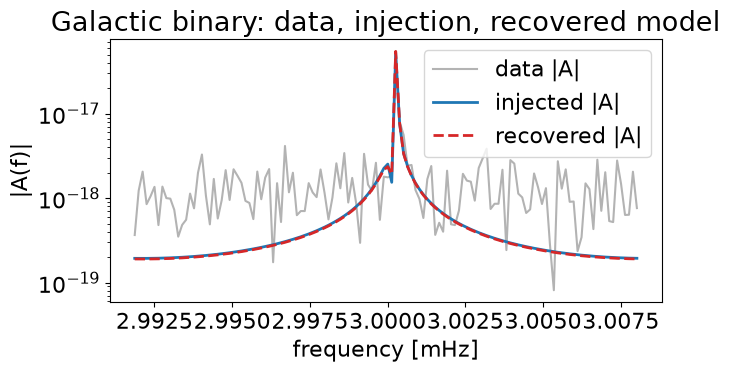

In [7]:
band = info["band"]
rsi, rhA, rhE = waveform(post.mean(0), ANGLES, Tobs, dt, NB)
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(
    freqs[band] * 1e3, np.abs(observed.tdi["A"][band]), color="0.7", label="data |A|"
)
ax.semilogy(
    freqs[band] * 1e3,
    np.abs(info["signal"]["A"][band]),
    "C0",
    lw=2,
    label="injected |A|",
)
ax.semilogy(
    freqs[rsi : rsi + NB] * 1e3, np.abs(rhA), "C3--", lw=2, label="recovered |A|"
)
ax.set_xlabel("frequency [mHz]")
ax.set_ylabel("|A(f)|")
ax.legend()
ax.set_title("Galactic binary: data, injection, recovered model")
plt.tight_layout()
plt.show()

## Where next

- **All eight parameters** — enlarge `init`/`BOUNDS`/`ANGLES` (in `gb_model` the
  angles are held fixed) to sample the sky/orientation too.
- **A handful of sources** — register several `GBBlock`s on one `Wheel`, each with
  its own `name=` (the Wheel rejects duplicates), band, and Eryn sampler. Then the ledger earns its keep: the Wheel hands each GB the data
  minus every *other* GB's current model — the blocked-Gibbs
  global fit enchilada orchestrates.
- **Sampled noise** — swap `FixedLISANoise` for a noise *block* that returns
  the residual with an updated `noise`; the GB block already re-reads
  `residual.noise_psd()` each `update`, so it tracks it for free.